# Problem statement

### Dataset
Predict House Prices

data set :-kc_house_data.csv.zip

Dataset Info –

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.

19 house features plus the price and the id columns, along with 21613 observations.


**Attributes of the dataset:**

Attribute Information:

id - a notation for a house

date -Date house was sold

price- Price is prediction target

bedrooms- Number of Bedrooms/House

bathrooms- Number of bathrooms/bedrooms

sqft_living- square footage of the home

sqft_lot- square footage of the lot

floors-Total floors (levels) in house

waterfront- House which has a view to a waterfront

view-Has been viewed

condition-How good the condition is ( Overall )

grade-overall grade given to the housing unit, based on King County grading system

sqft_above-square footage of house apart from basement

sqft_basement-square footage of the basement

yr_built-Built Year

yr_renovated-Year when house was renovated

zipcode-zip

lat-Latitude coordinate

long-Longitude coordinate

sqft_living15-Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area-

sqft_lot15

lotSize area in 2015(implies-- some renovations)


# import the required libraries

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#read the dataset into house_data DataFrame
house_data = pd.read_csv('kc_house_data.csv')

# Explore Data Analysis and Insights

In [4]:
#shape, shows we have 21613 rows and 21 columns
house_data.shape

(21613, 21)

In [5]:
#data types
house_data.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [6]:
#date is the object,rest all features are int and float.

In [7]:
#take a glance of the data by selecting first 5 rows
house_data.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [8]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null object
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: float64(5), int64(15), object(1)
memory usage: 3.5+ MB


In [9]:
#info shows we have 1 object, 15 int and 4 float features.
#Each features have all the 21613 values, there are no missing values

In [33]:
pd.isna(house_data).count()

id               21613
date             21613
price            21613
bedrooms         21613
bathrooms        21613
sqft_living      21613
sqft_lot         21613
floors           21613
waterfront       21613
view             21613
condition        21613
grade            21613
sqft_above       21613
sqft_basement    21613
yr_built         21613
yr_renovated     21613
zipcode          21613
lat              21613
long             21613
sqft_living15    21613
sqft_lot15       21613
dtype: int64

In [10]:
house_data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [11]:
#Insights
#the bedroom columns , the dataset has a house where the house has 33 bedrooms.
#Maximum square feet is 13,450 where as the minimum is 290. we can see that the data is distributed.
#Waterfront has binary values, just 0s and 1s

In [12]:
#Lets try to check the distrubution of each feature against price

<function seaborn.utils.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)>

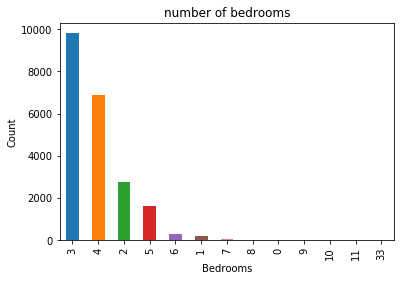

In [13]:
house_data['bedrooms'].value_counts().plot(kind='bar')
plt.title('number of bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
sns.despine

In [14]:
#As we can see from the visualization 3 bedroom houses are most commonly sold followed by 4 bedroom
#now we know that 3 and 4 bedroom’s are highest selling.
#Lets try to find out the highest selling houses at which locality.

In [18]:
#we have latitude and longitude on the dataset for each house.
#We are going to see the common location and how the houses are placed.

C:\Users\muzzammil\Anaconda3\lib\site-packages\seaborn\axisgrid.py:2262: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 720x720 with 0 Axes>

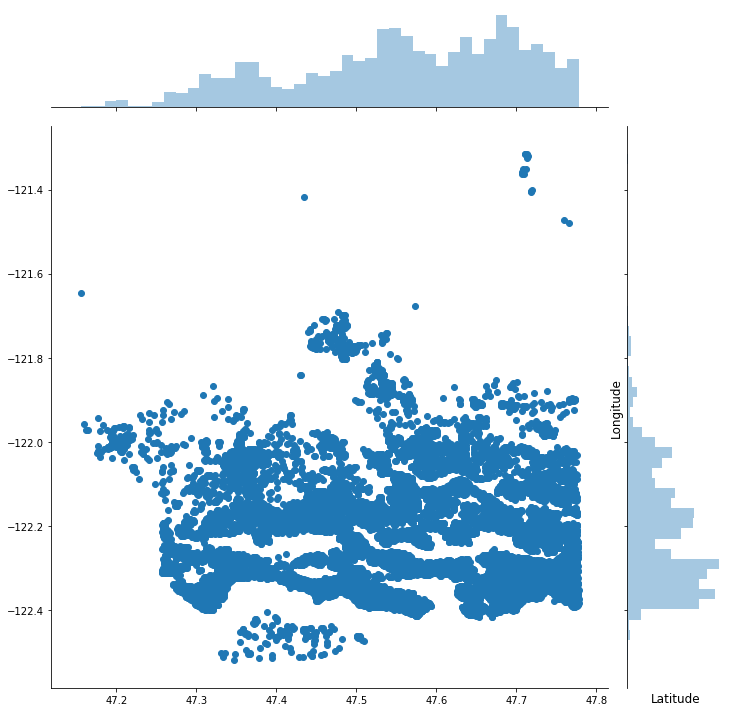

<function seaborn.utils.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)>

In [19]:
plt.figure(figsize=(10,10))
sns.jointplot(x=house_data.lat.values,y=house_data.long.values,size=10)
plt.xlabel('Latitude',fontsize=12)
plt.ylabel('Longitude',fontsize=12)
plt.show()
sns.despine

In [20]:
#Joinplot function helps us see the concentration of data and placement of data and can be really useful.
#For latitude between -47.7 and -48.8 there are many houses , which would mean that maybe it’s an ideal location. 
#But when we talk about longitude we can see that concentration is high between -122.2 to -122.4. 
#Which would mean that most of the buy’s has been for this particular location.

In [21]:
#Lest check if any other factors impact the price of the house

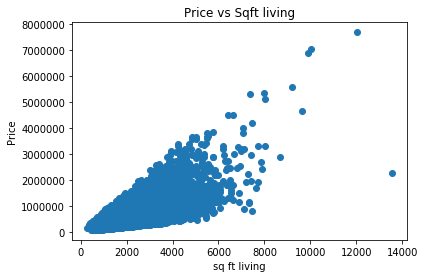

<Figure size 432x288 with 0 Axes>

In [22]:
plt.scatter(house_data.sqft_living,house_data.price)
plt.title('Price vs Sqft living')
plt.xlabel('sq ft living')
plt.ylabel('Price')
plt.show()
sns.despine()

In [25]:
#we can see that more the living area , more the price though data is concentrated towards a particular price zone,
#but from the figure we can see that the data points seem to be in linear direction.
#we can also see some irregularities that the house with the highest square feet was sold for very less
#maybe there is another factor or probably the data must be wrong.

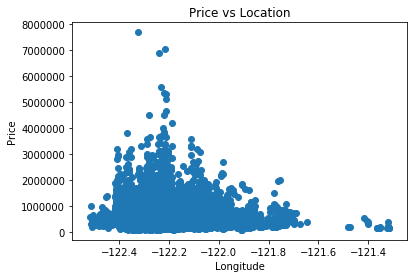

<Figure size 432x288 with 0 Axes>

In [23]:
plt.scatter(house_data.long,house_data.price)
plt.title('Price vs Location')
plt.xlabel('Longitude')
plt.ylabel('Price')
plt.show()
sns.despine()

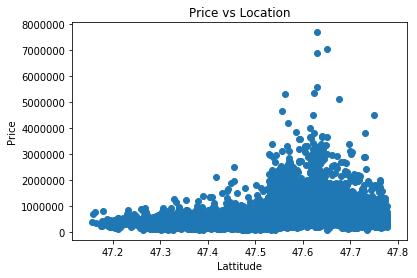

<Figure size 432x288 with 0 Axes>

In [27]:
plt.scatter(house_data.lat,house_data.price)
plt.title('Price vs Location')
plt.xlabel('Lattitude')
plt.ylabel('Price')
plt.show()
sns.despine()

In [26]:
#The above figure depicts that  -122.2 to -122.4 sells houses at much higher amount.

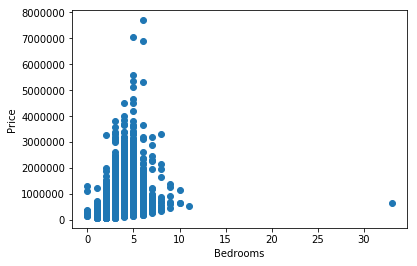

<Figure size 432x288 with 0 Axes>

In [24]:
plt.scatter(house_data.bedrooms,house_data.price)
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()
sns.despine()

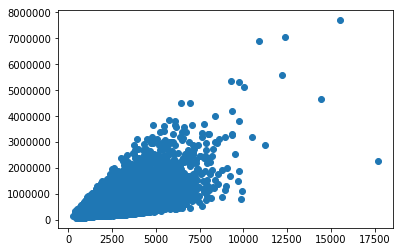

In [28]:
plt.scatter((house_data['sqft_living']+house_data['sqft_basement']),house_data['price'])

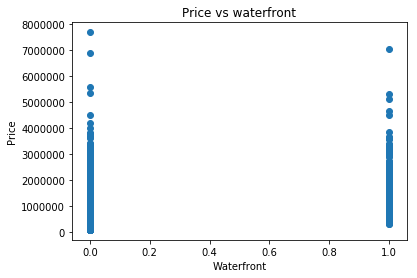

<Figure size 432x288 with 0 Axes>

In [29]:
plt.scatter(house_data.waterfront,house_data.price)
plt.title('Price vs waterfront')
plt.xlabel('Waterfront')
plt.ylabel('Price')
plt.show()
sns.despine()

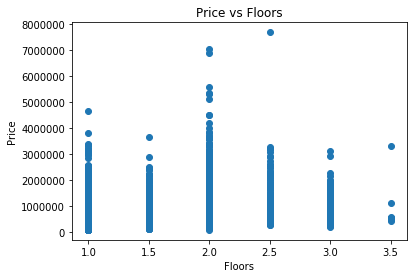

<Figure size 432x288 with 0 Axes>

In [30]:
plt.scatter(house_data.floors,house_data.price)
plt.title('Price vs Floors')
plt.xlabel('Floors')
plt.ylabel('Price')
plt.show()
sns.despine()

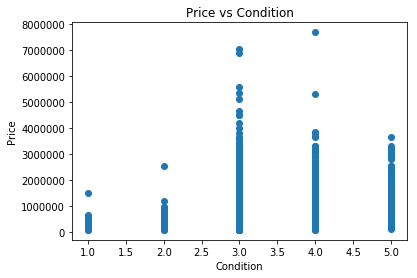

<Figure size 432x288 with 0 Axes>

In [31]:
plt.scatter(house_data.condition,house_data.price)
plt.title('Price vs Condition')
plt.xlabel('Condition')
plt.ylabel('Price')
plt.show()
sns.despine()

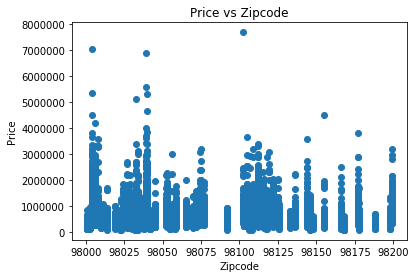

<Figure size 432x288 with 0 Axes>

In [32]:
plt.scatter(house_data.zipcode,house_data.price)
plt.title('Price vs Zipcode')
plt.xlabel('Zipcode')
plt.ylabel('Price')
plt.show()
sns.despine()

In [34]:
#As we can see from all the above representation that many factors are affecting the prices of the house , 
#like square feet which increases the price of the house and even location influencing the prices of the house.

In [4]:
#taking copy of the original data
house_data_copy = house_data.copy()

In [5]:
#since id and date do not have much of significance,we can drop that for our data insight analysis
#waterfront and view binary as they do not have impact on the linear model,so dropping the same
house_data = house_data.drop(['id','date','waterfront','view'],axis=True)

In [37]:
house_data.dtypes

price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [6]:
house_data.shape

(21613, 17)

In [7]:
#now we are left with 17 features, lets do a multivariate analysis to get more insights

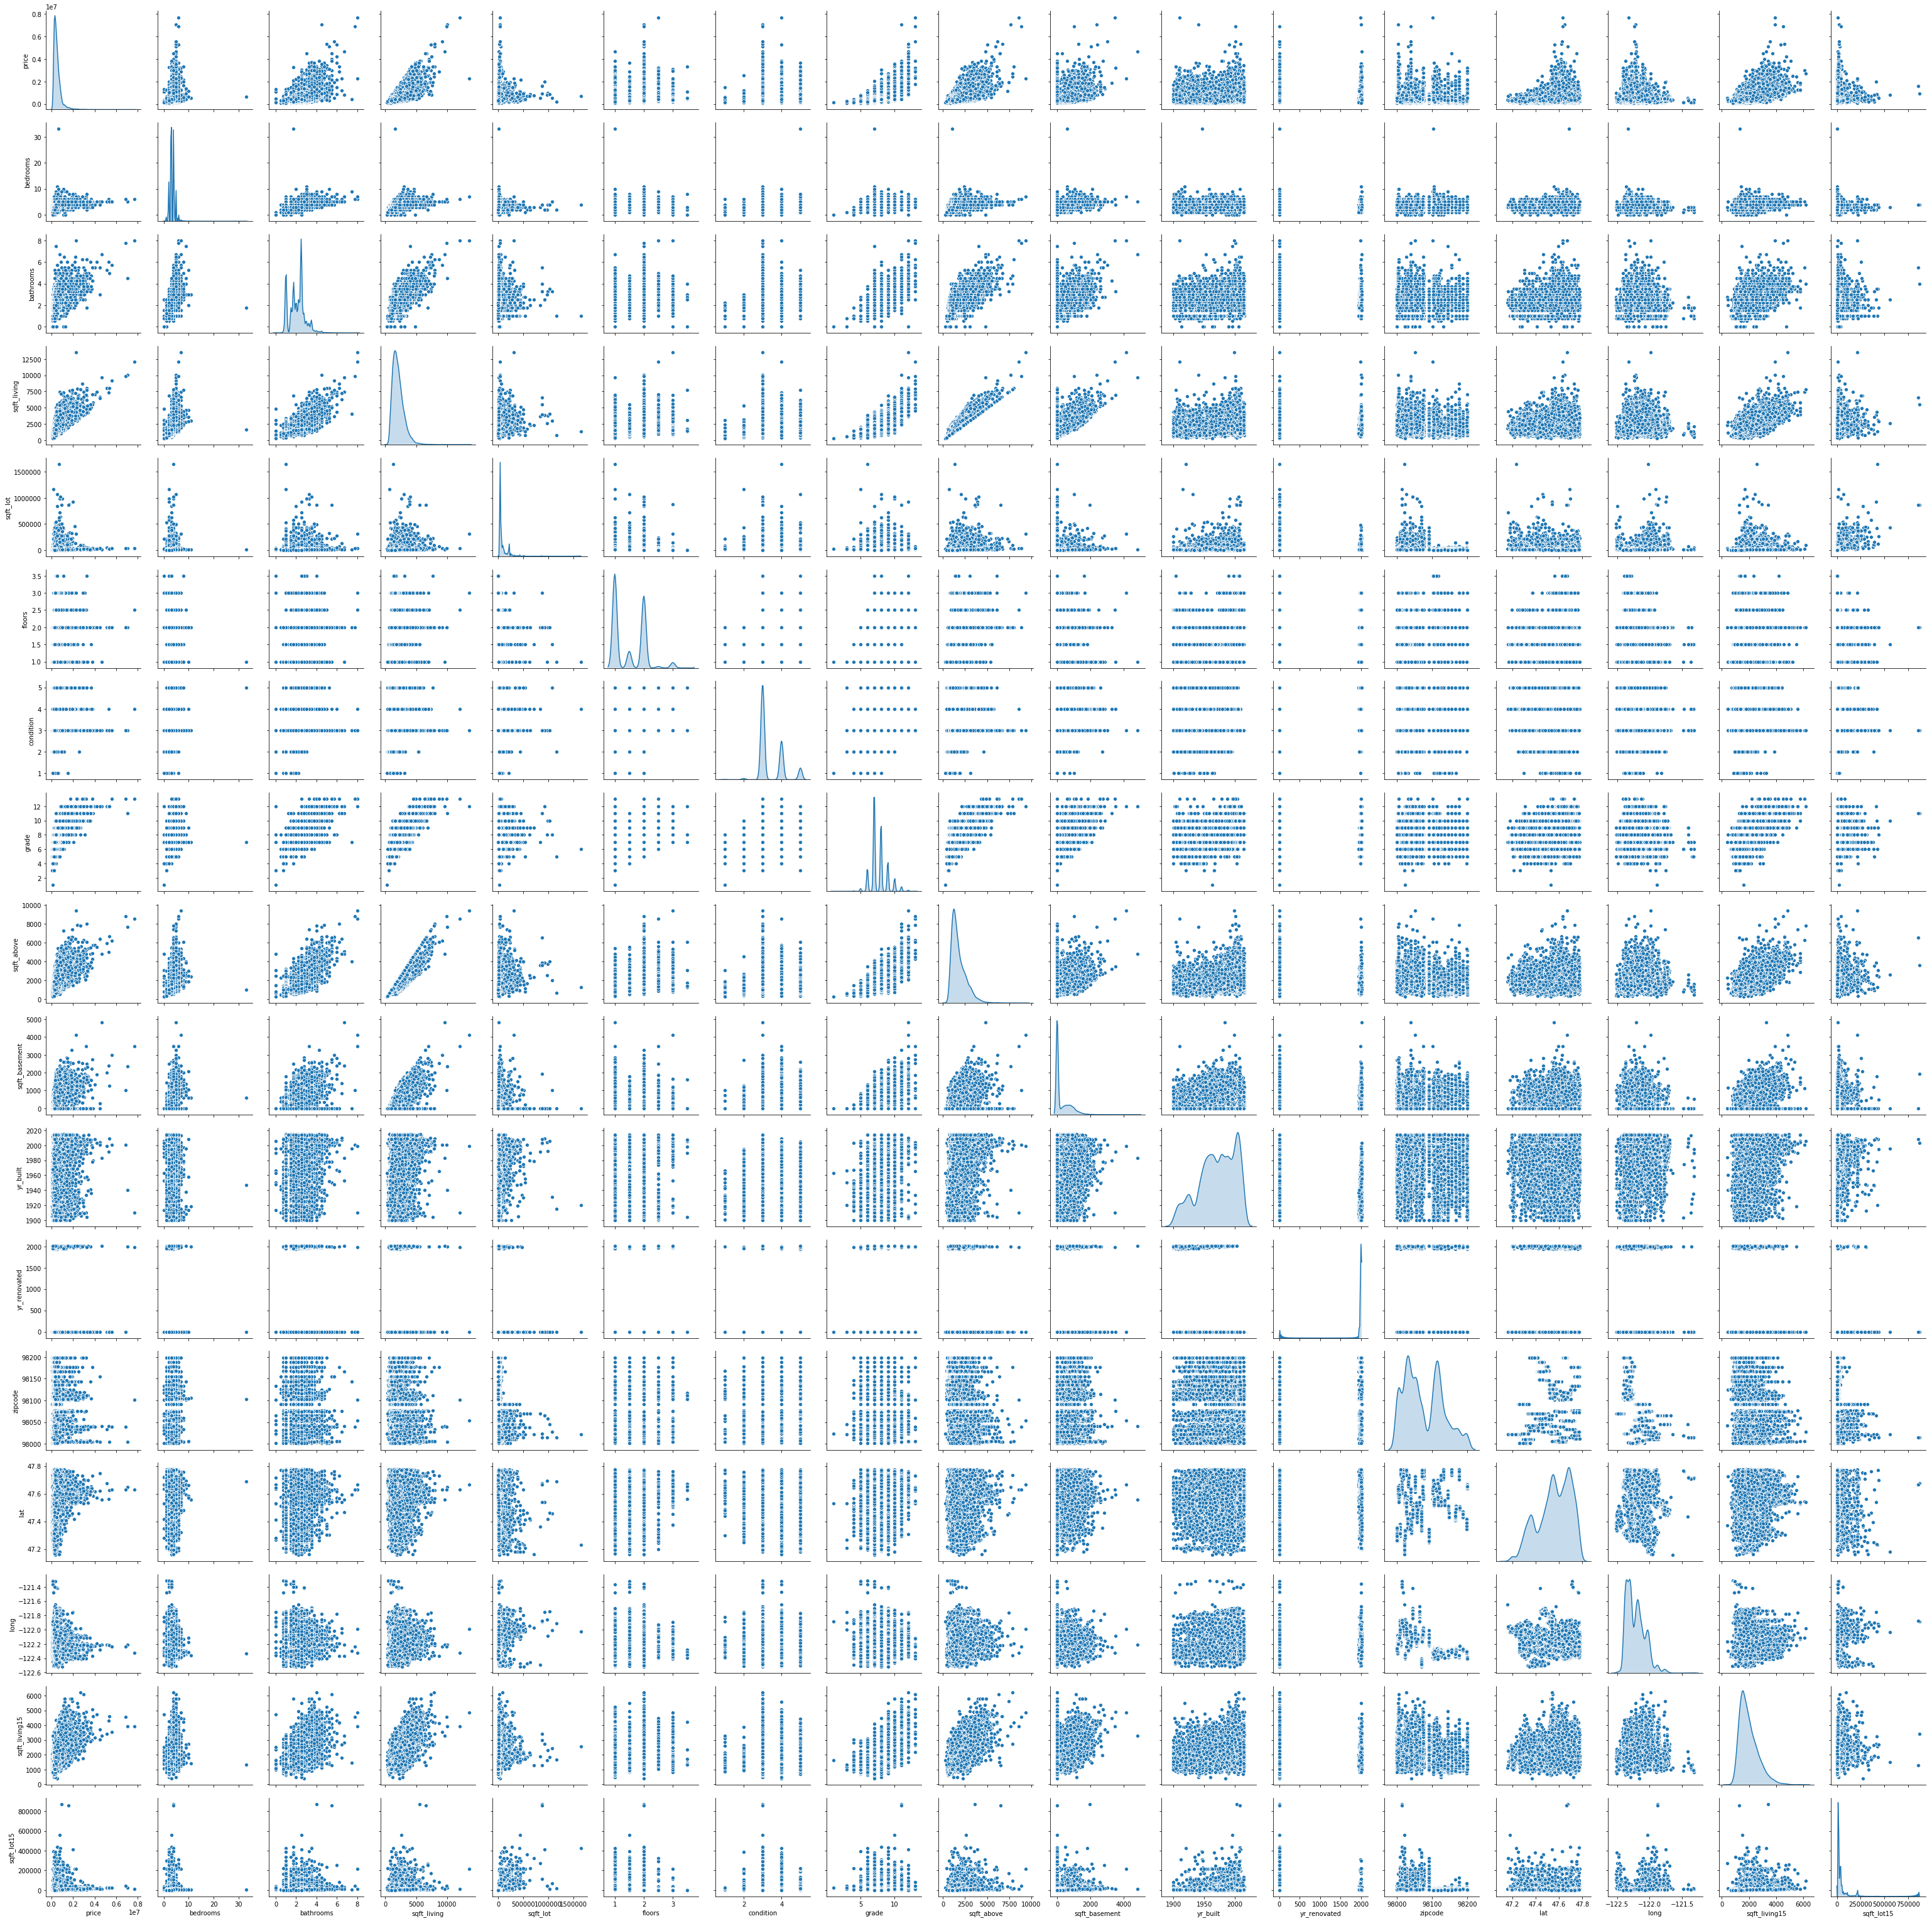

In [8]:
sns.pairplot(house_data,diag_kind='kde')

In [12]:
#apart from the observations above with price against individual features we see
#linear relation between price and sq ft living
#same for sq ft above and sq ft living(highly correlated).
#sq ft and bathrooms,sqft living vs grade

In [10]:
#Lets look at the coorelation using heatmap.

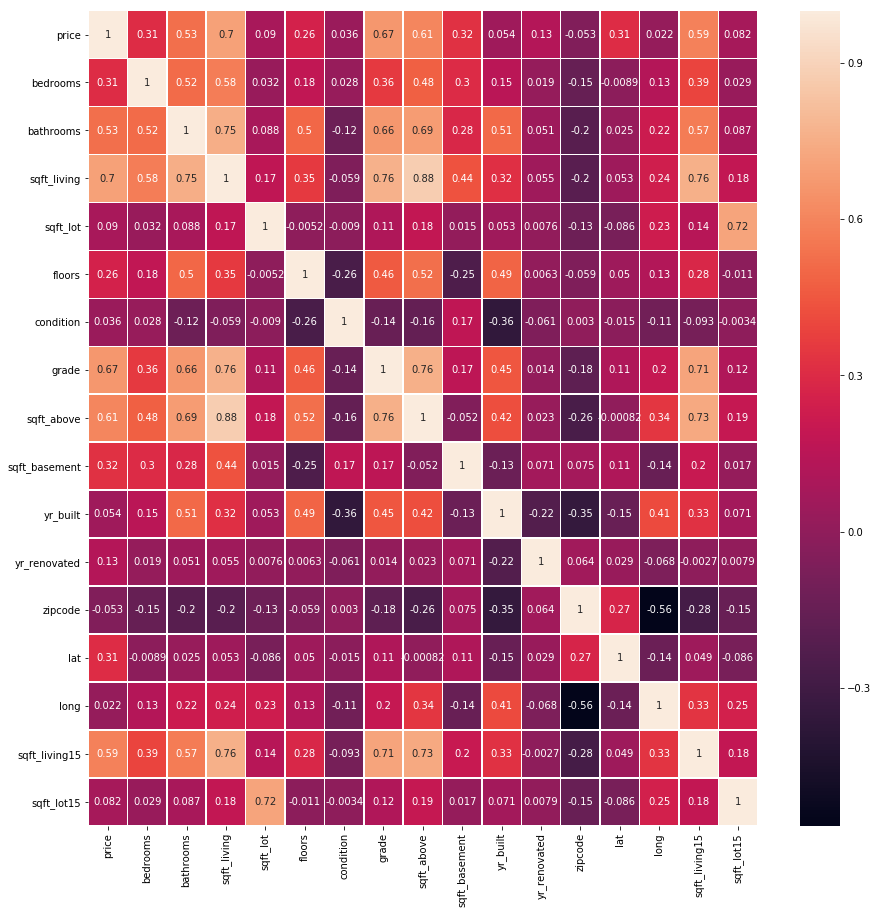

In [11]:
correlation = house_data.corr()
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(correlation,annot=True,linewidths=0.5,ax=ax)

In [13]:
#define the dependant and independant variable
#Split the data in train and test with 70:30 ration.

In [14]:
from sklearn.model_selection import train_test_split
X = house_data.drop('price',axis=1)
y = house_data['price']
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=5)
print('shape of xtrain:',xtrain.shape)
print('shape of xtest:',xtest.shape)

shape of xtrain: (15129, 16)
shape of xtest: (6484, 16)


In [16]:
#Now get the p-value summary of features and get the list of features, which you can remove
#i.e. the ones which have p-value > α (0.05 being default here)
import statsmodels.api as sm
ols = sm.OLS(y,X)

In [17]:
results = ols.fit()

In [18]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                 1.202e+04
Date:                Sun, 14 Jul 2019   Prob (F-statistic):               0.00
Time:                        23:00:59   Log-Likelihood:            -2.9590e+05
No. Observations:               21613   AIC:                         5.918e+05
Df Residuals:                   21598   BIC:                         5.919e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
bedrooms      -4.633e+04   1991.837    -23.258      0.000   -5.02e+04   -4.24e+04
bathrooms      4.312e+04   3453.337     12.488      0.000    3.64e+04    4.99e+04
sqft_living     122.4053      2.392     51.166      0.000     117.716     127.094
sqft_lot          0.1545      0.051      3.042      0.002       0.055       0.254
floors         1.224e+04   3755.131      3.259      0.001    4876.348    1.96e+04
condition      2.856e+04   2466.682     11.577      0.000    2.37e+04    3.34e+04
grade          1.015e+05   2267.506     44.752      0.000     9.7e+04    1.06e+05
sqft_above       64.5147      2.356     27.382      0.000      59.897      69.133
sqft_basement    57.8906      2.731     21.201      0.000      52.538      63.243
yr_built      -2881.4687     71.564    -40.264      0.000   -3021.740   -2741.198
yr_renovated     34.4380      3.860      8.922      0.000      26.872      42.004
zipcode        -530.3952     18.921    -28.033      0.000    -567.481    -493.309
lat            5.562e+05   1.13e+04     49.058      0.000    5.34e+05    5.78e+05
long          -2.495e+05   1.38e+04    -18.017      0.000   -2.77e+05   -2.22e+05
sqft_living15    39.2270      3.563     11.010      0.000      32.244      46.210
sqft_lot15       -0.3323      0.078     -4.275      0.000      -0.485      -0.180
==============================================================================
Omnibus:                    19506.924   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1940369.333
Skew:                           3.957   Prob(JB):                         0.00
Kurtosis:                      48.739   Cond. No.                     6.26e+16
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 5.59e-20. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [19]:
results.params

bedrooms         -46326.557027
bathrooms         43124.071464
sqft_living         122.405274
sqft_lot              0.154534
floors            12236.682467
condition         28556.458745
grade            101476.021815
sqft_above           64.514676
sqft_basement        57.890598
yr_built          -2881.468712
yr_renovated         34.438044
zipcode            -530.395168
lat              556156.556053
long            -249523.731047
sqft_living15        39.227037
sqft_lot15           -0.332284
dtype: float64

In [20]:
#There is nothing with p value > 0.05 hence we continue using all the features.

# Build a linear regression model to predict the house prices

In [21]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(xtrain,ytrain)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [22]:
print('Train score:',reg.score(xtrain,ytrain))
print('Test score:',reg.score(xtest,ytest))

Train score: 0.6583938275445285
Test score: 0.6682889100491392


In [23]:
list(zip(X.columns,reg.coef_))

[('bedrooms', -43722.82712907352),
 ('bathrooms', 41329.33490653604),
 ('sqft_living', 120.88839688743428),
 ('sqft_lot', 0.192241712109535),
 ('floors', 9363.250550944143),
 ('condition', 29372.871033218824),
 ('grade', 102582.29042778724),
 ('sqft_above', 65.67034321440951),
 ('sqft_basement', 55.21805371867549),
 ('yr_built', -2846.3369578680686),
 ('yr_renovated', 35.98430545940255),
 ('zipcode', -442.5365278010805),
 ('lat', 554242.7530735192),
 ('long', -243485.7073473656),
 ('sqft_living15', 36.56491444423409),
 ('sqft_lot15', -0.3586017509587691)]

In [24]:
#Lets build a Gradient boost regressor without any tuning to find out if any change is score.

In [25]:
from sklearn.ensemble import GradientBoostingRegressor
grb = GradientBoostingRegressor()

In [26]:
grb.fit(xtrain,ytrain)

GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.1, loss='ls', max_depth=3, max_features=None,
             max_leaf_nodes=None, min_impurity_decrease=0.0,
             min_impurity_split=None, min_samples_leaf=1,
             min_samples_split=2, min_weight_fraction_leaf=0.0,
             n_estimators=100, n_iter_no_change=None, presort='auto',
             random_state=None, subsample=1.0, tol=0.0001,
             validation_fraction=0.1, verbose=0, warm_start=False)

In [27]:
grb.score(xtest,ytest)

0.832917740008839

In [28]:
#We can see that there has been improvment in the accuracy score from 67% for Linear model to 83% for Gradient boost.

In [29]:
#Lets use Gridsearch to get the best hyper parameters for gradient boost.
#we are checking the estimators from 50 to 400 with a range of 50 each.
# and for max depth from 3 to 6 with a cross validation of 5 folds
from sklearn.model_selection import GridSearchCV
parameter={'n_estimators':range(50,400,50),'max_depth':range(3,6)}
GS=GridSearchCV(grb,parameter,cv=5)
GS.fit(X,y)

GridSearchCV(cv=5, error_score='raise-deprecating',
       estimator=GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.1, loss='ls', max_depth=3, max_features=None,
             max_leaf_nodes=None, min_impurity_decrease=0.0,
             min_impurity_split=None, min_samples_leaf=1,
             min_sampl...=None, subsample=1.0, tol=0.0001,
             validation_fraction=0.1, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': range(50, 400, 50), 'max_depth': range(3, 6)},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [30]:
print('Best parameter:',GS.best_params_)
print('Best Score:',GS.best_score_)

Best parameter: {'max_depth': 5, 'n_estimators': 350}
Best Score: 0.8567804026131142


In [31]:
#Lets try to build the model with the above hyper parameters.

In [32]:
grb1 = GradientBoostingRegressor(n_estimators=350,max_depth=5,loss='ls',random_state=0)
grb1.fit(xtrain,ytrain)

GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.1, loss='ls', max_depth=5, max_features=None,
             max_leaf_nodes=None, min_impurity_decrease=0.0,
             min_impurity_split=None, min_samples_leaf=1,
             min_samples_split=2, min_weight_fraction_leaf=0.0,
             n_estimators=350, n_iter_no_change=None, presort='auto',
             random_state=0, subsample=1.0, tol=0.0001,
             validation_fraction=0.1, verbose=0, warm_start=False)

In [33]:
print('Train score:',grb1.score(xtrain,ytrain))
print('Train score:',grb1.score(xtest,ytest))

Train score: 0.9670935890669113
Train score: 0.8577969460467515


In [34]:
#We can see the score has improved to 86%

In [35]:
#use the cross val score to with 5 folds  

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(grb1,xtrain,ytrain,cv=5)
print(cv_scores)
print("Average 5-Fold CV Score: {}".format(np.mean(cv_scores)))

[0.85501215 0.83466807 0.83478233 0.86125057 0.86930396]
Average 5-Fold CV Score: 0.8510034144057371


In [36]:
#Lets try to use PCA to create new features and build new models using those features.

In [37]:
#Standard Scalar
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
pd.DataFrame(X_std).describe().T

C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


,count,mean,std,min,25%,50%,75%,max
0,21613.0,-1.254167e-15,1.000023,-3.624404,-0.398737,-0.398737,0.676485,31.857929
1,21613.0,-1.051951e-15,1.000023,-2.745920,-0.473621,0.175607,0.500221,7.641730
2,21613.0,3.174253e-16,1.000023,-1.948891,-0.710895,-0.184991,0.511858,12.478065
3,21613.0,3.281921e-17,1.000023,-0.352176,-0.243049,-0.180808,-0.106688,39.504338
4,21613.0,-1.753125e-14,1.000023,-0.915427,-0.915427,0.010539,0.936506,3.714405
5,21613.0,-2.636807e-15,1.000023,-3.702668,-0.629187,-0.629187,0.907554,2.444294
6,21613.0,-2.328998e-15,1.000023,-5.663344,-0.558836,-0.558836,0.291916,4.545672
7,21613.0,3.892022e-16,1.000023,-1.809494,-0.722631,-0.275810,0.509146,9.204044
8,21613.0,-2.022801e-15,1.000023,-0.658681,-0.658681,-0.658681,0.606670,10.232379
9,21613.0,3.592925e-15,1.000023,-2.417383,-0.681079,0.136006,0.885000,1.497813


In [38]:
# PCA
# Step 1 - Create covariance matrix

cov_matrix = np.cov(X_std.T)

#print('Covariance Matrix \n%s', cov_matrix)


In [39]:
# Step 2- Get eigen values and eigen vector
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
#print('Eigen Vectors \n%s', eig_vecs)
#print('\n Eigen Values \n%s', eig_vals)

In [40]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 32.31542104  45.08894089  56.32903231  64.56504432  70.92797375
  76.40039966  81.62507686  85.64531038  89.41772811  91.95506357
  94.00094885  95.78564769  97.38908706  98.80494592 100.
 100.        ]


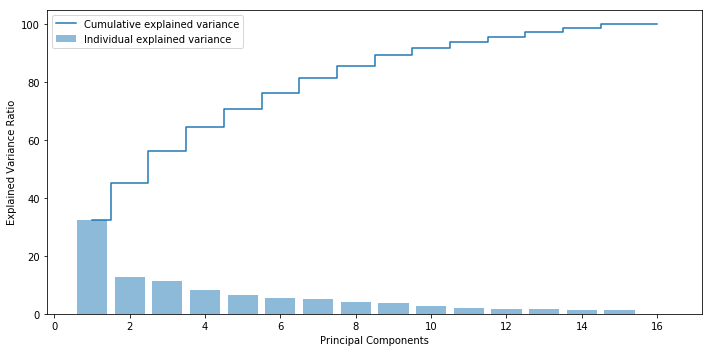

In [41]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [42]:
#from the above plot lets use 7 create 7 new components 

In [43]:
from sklearn.decomposition import PCA
pca = PCA(n_components=7)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=7, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [44]:
x_transformed = pd.DataFrame(pca.transform(X_std))
x_transformed.shape


x_trans = pca.fit_transform(X_std)

In [45]:
x_transformed.columns = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7']
x_transformed.describe()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
count,2.161300e+04,2.161300e+04,2.161300e+04,2.161300e+04,2.161300e+04,2.161300e+04,2.161300e+04
mean,-9.348414e-16,4.650886e-17,-2.020007e-16,2.330169e-16,8.682783e-17,-1.286981e-16,-1.982816e-17
std,2.273919e+00,1.429636e+00,1.341081e+00,1.147965e+00,1.009017e+00,9.357503e-01,9.143233e-01
min,-5.216229e+00,-9.914262e+00,-3.138745e+00,-8.075925e+00,-5.391383e+00,-4.975152e+00,-4.241625e+00
25%,-1.649774e+00,-8.416080e-01,-9.122395e-01,-7.629153e-01,-4.977570e-01,-7.308696e-01,-5.408209e-01
50%,-2.597267e-01,5.402820e-02,-4.930796e-02,-4.072746e-02,-1.889290e-01,-4.114656e-02,5.556483e-03
75%,1.393844e+00,8.872245e-01,6.394346e-01,6.900702e-01,1.764895e-01,6.854511e-01,5.798002e-01
max,1.876873e+01,1.767351e+01,2.781439e+01,1.866242e+01,5.906112e+00,6.408201e+00,4.547331e+00


In [46]:
final_data = pd.concat([house_data,x_transformed],axis=1)
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 24 columns):
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
PC1              21613 non-null float64
PC2              21613 non-null float64
PC3              21613 non-null float64
PC4              21613 non-null float64
PC5              21613 non-null float64
PC6              21613 non-null flo

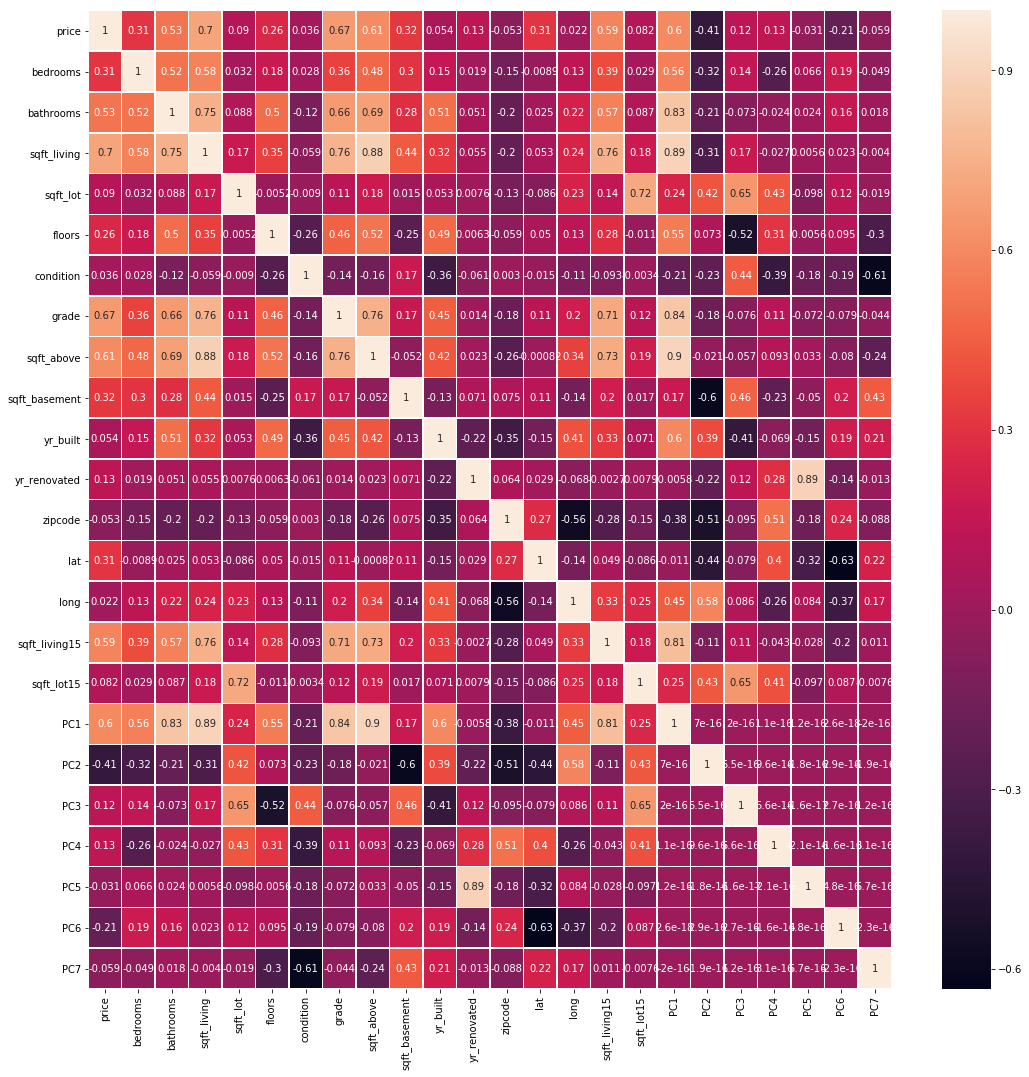

In [47]:
corr1 = final_data.corr()
fig, ax = plt.subplots(figsize=(18,18))
sns.heatmap(corr1,annot=True,linewidths=0.5,ax=ax)

In [48]:
Xtra,Xtes,ytra,ytes = train_test_split(x_transformed,y,test_size=0.3,random_state=7)
print('shape of xtrain:',Xtra.shape)
print('shape of xtest:',Xtes.shape)

shape of xtrain: (15129, 7)
shape of xtest: (6484, 7)


In [49]:
reg_model = LinearRegression()
reg_model.fit(Xtra,ytra)
print('Train score:',reg_model.score(Xtra,ytra))
print('Train score:',reg_model.score(Xtes,ytes))

Train score: 0.6135123776720446
Train score: 0.5931902442212281


In [50]:
grb2 = GradientBoostingRegressor(n_estimators=350,max_depth=5,loss='ls')
grb2.fit(Xtra,ytra)
print('Train score:',grb2.score(Xtra,ytra))
print('Train score:',grb2.score(Xtes,ytes))

Train score: 0.91668296284666
Train score: 0.7491247660820045


In [51]:
#WE can see that creating new features did not improve the accuracy.

In [52]:
#Lets try to compare the models we have built using box plot to decide the best model.

In [53]:
models = []
models.append(('Linear Reg', reg))
models.append(('Lin Reg PCA', reg_model))
models.append(('Gradient Boost', grb))
models.append(('Grb tune', grb1))
models.append(('Grb tune PCA', grb2))

In [54]:
X = house_data.drop(['price'],axis=1)
Y = house_data[['price']]

C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

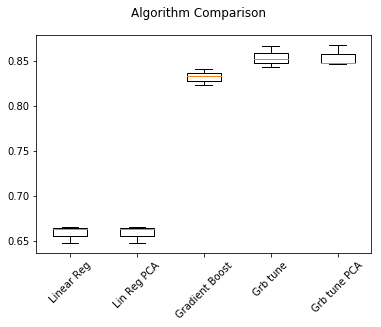

In [56]:
from sklearn import model_selection
from sklearn.model_selection import KFold,cross_val_score
# evaluate each model in turn
results = []
names = []
for name, model in models:
	kfold = model_selection.KFold(n_splits=3,random_state=2)
	cv_results = model_selection.cross_val_score(model, X, Y, cv=kfold)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), np.var(cv_results))
	#print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names,rotation=45)
plt.show()

In [57]:
cv_results

array([0.847481  , 0.86692976, 0.84603934])

In [58]:
#Using 3 folds for all the build modesl to compare the accuracy and variance.
#from the above we could see that the tuned Gradient boost model has better accuracy score and explains the variance well.

# END of Assignment